# 📰 Fake News Detection — Deep Learning Approach (RNNs)

> **Project:** Orbyx — Task 2  
> **Approach:** Deep Learning — Simple RNN · LSTM · GRU (PyTorch)  
> **Dataset:** [Fake and Real News Dataset — Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)  
> **Research grounding:** Lilhore et al. (2025) — *Fake News Detection Using BERT and Bi-LSTM with Grid Search Hyperparameter Optimization*  
> **Date:** February 2026

---

## 🗺️ Notebook Structure

| Step | Section |
|------|---------|
| 1 | Data Understanding |
| 2 | Text Preprocessing |
| 3 | Text → Sequences & Padding |
| 4 | Model Development (RNN / LSTM / GRU) |
| 5 | Model Training |
| 6 | Evaluation & Comparison |
| 7 | Summary & Research Connection |

---
## ⚙️ 0 — Imports & Setup

In [20]:
# ── Standard ──────────────────────────────────────────────────────────────────
import re
import time
import warnings
import numpy  as np
import pandas as pd
from collections import Counter
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
for pkg in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Sklearn (evaluation only) ─────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries loaded.  Device: {DEVICE}")

✅ Libraries loaded.  Device: cuda


---
## 📂 1 — Data Understanding

Same dataset as the ML notebook — two CSV files (`True.csv`, `Fake.csv`) sourced from Reuters and various misinformation sites.

| File | Label | Source |
|------|-------|--------|
| `True.csv` | `1` (REAL) | Reuters |
| `Fake.csv` | `0` (FAKE) | Misinformation sites |

In [21]:
# ── 1.1  Load ─────────────────────────────────────────────────────────────────


real_df = pd.read_csv("/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv")
fake_df = pd.read_csv("/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv")

# Numeric labels:  1 = REAL,  0 = FAKE
real_df["label"] = 1
fake_df["label"] = 0

df = pd.concat([real_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Total samples : {len(df):,}")
print(f"Columns       : {list(df.columns)}")
df.head()

Total samples : 44,898
Columns       : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


label
FAKE    23481
REAL    21417
Name: count, dtype: int64


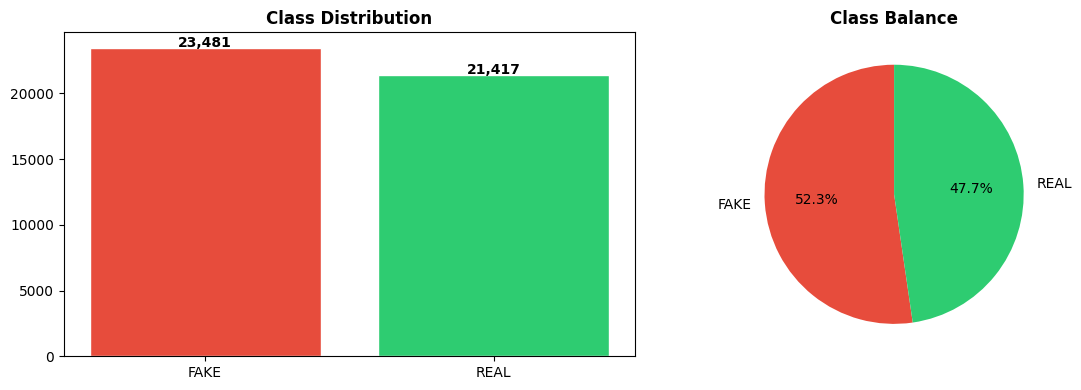

In [22]:
# ── 1.2  Class distribution ───────────────────────────────────────────────────
counts = df["label"].value_counts().rename({1: "REAL", 0: "FAKE"})
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values, color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance', fontweight='bold')

plt.tight_layout(); plt.show()

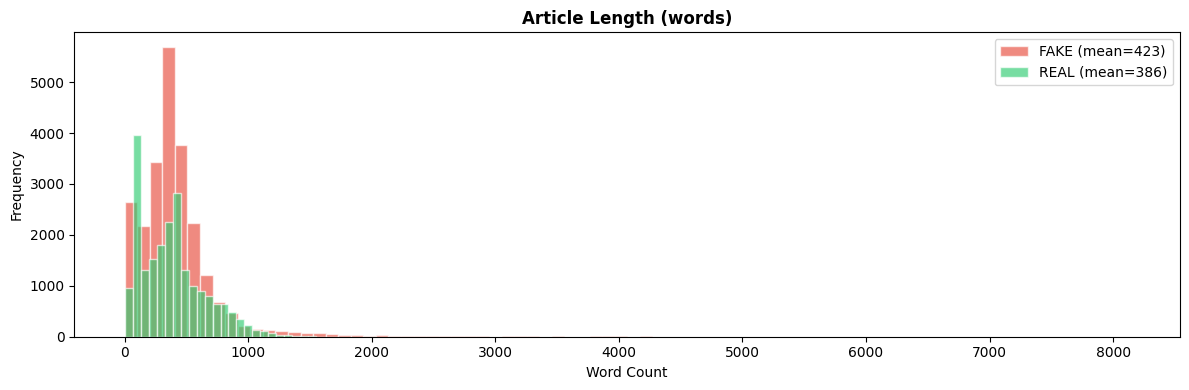

95th percentile length : 904 words
Max length             : 8135 words


In [23]:
# ── 1.3  Article length distribution ─────────────────────────────────────────
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(12, 4))
for lbl, color, name in [(0,'#e74c3c','FAKE'), (1,'#2ecc71','REAL')]:
    sub = df[df["label"] == lbl]["word_count"]
    ax.hist(sub, bins=80, alpha=0.65,
            label=f"{name} (mean={sub.mean():.0f})",
            color=color, edgecolor='white')
ax.set_title('Article Length (words)', fontweight='bold')
ax.set_xlabel('Word Count'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()

print(f"95th percentile length : {int(df['word_count'].quantile(0.95))} words")
print(f"Max length             : {df['word_count'].max()} words")

---
## 🧹 2 — Text Preprocessing

The deep learning pipeline differs from the ML one in two key ways:
- We **do NOT lemmatize** — the Embedding layer will learn word representations anyway.
- We **build a vocabulary** from training data only (no test leakage).

| Step | Reason |
|------|---------|
| Lowercase | Normalise casing |
| Regex clean | Remove URLs, HTML, punctuation, digits |
| Stopword removal | Reduce noise and vocabulary size |
| Tokenize | Split into word tokens (NLTK) |

In [24]:
# ── 2.1  Preprocessing function ───────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text: str) -> list[str]:
    """
    Clean and tokenize a news article, while removing publisher tags
    and data leakage cheat codes ('reuters', 'said').

    Returns
    -------
    list[str]
        Ordered list of cleaned word tokens.
    """
    # Ensure text is a string
    text = str(text)
    
    # NEW: Strip standard datelines (e.g., "WASHINGTON (Reuters) - ")
    text = re.sub(r'^.*?- ', '', text, count=1) if '(Reuters)' in text else text
    
    # Lowercasing
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # NEW: Explicitly remove data leakage keywords ('reuters' and 'said')
    text = re.sub(r'\b(reuters|said)\b', ' ', text)
    
    # Remove non-alphabetical characters (digits, punctuation)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Collapse multiple whitespace into one
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize and remove stopwords / short words
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    
    return tokens


# ── 2.2  Apply ────────────────────────────────────────────────────────────────
print("Preprocessing text … (may take ~1 min)")
df["tokens"] = df["text"].apply(preprocess)
print("✅ Done.")

# Preview
print("\nSample tokens (first article):")
print(df["tokens"].iloc[0][:20])

Preprocessing text … (may take ~1 min)
✅ Done.

Sample tokens (first article):
['donald', 'trump', 'white', 'house', 'chaos', 'trying', 'cover', 'russia', 'problems', 'mounting', 'hour', 'refuse', 'acknowledge', 'problems', 'surrounding', 'fake', 'news', 'hoax', 'however', 'facts']


---
## 🔢 3 — Text → Sequences & Padding

RNN models require fixed-length numerical inputs.

**Pipeline:**
1. Split data first (`train` / `val` / `test`) — vocabulary is built **only from training tokens**.
2. Build `word → index` mapping (special tokens: `<PAD>=0`, `<UNK>=1`).
3. Convert every article's token list to an integer sequence.
4. Truncate long sequences and pad short ones to `MAX_LEN`.

In [25]:
# ── 3.1  Train / Val / Test split ────────────────────────────────────────────
X_all = df["tokens"].values
y_all = df["label"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_STATE, stratify=y_all)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.12, random_state=RANDOM_STATE, stratify=y_train)

print(f"Train : {len(X_train_raw):,}")
print(f"Val   : {len(X_val_raw):,}")
print(f"Test  : {len(X_test_raw):,}")

Train : 33,583
Val   : 4,580
Test  : 6,735


In [26]:
# ── 3.2  Build Vocabulary (training tokens ONLY) ──────────────────────────────
VOCAB_SIZE  = 30_000    # keep top-N most frequent words
PAD_IDX     = 0
UNK_IDX     = 1

# Count word frequencies
counter = Counter(token for seq in X_train_raw for token in seq)
most_common = counter.most_common(VOCAB_SIZE - 2)   # -2 for <PAD> and <UNK>

# Build word → index mapping
word2idx = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
word2idx.update({word: idx + 2 for idx, (word, _) in enumerate(most_common)})
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)   # actual vocab size (may be < 30000)
print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"Sample entries  : { {k: word2idx[k] for k in list(word2idx)[:8]} }")

Vocabulary size : 30,000
Sample entries  : {'<PAD>': 0, '<UNK>': 1, 'trump': 2, 'president': 3, 'would': 4, 'people': 5, 'one': 6, 'state': 7}


MAX_LEN (90th pct of train) : 417 tokens


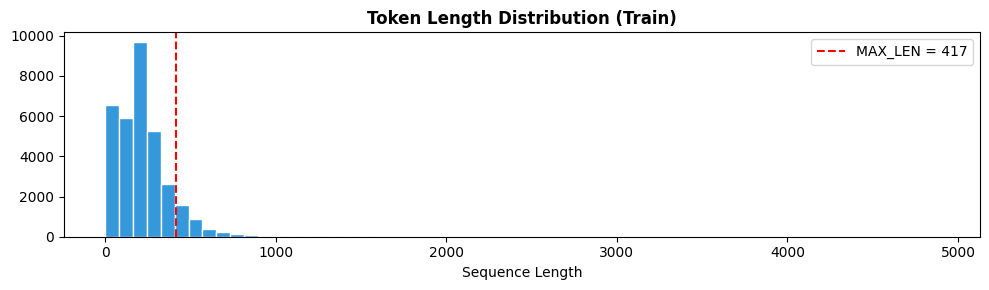

In [27]:
# ── 3.3  Choose MAX_LEN based on the data ────────────────────────────────────
# Use 90th percentile of training sequence lengths → reasonable coverage without waste
train_lengths = [len(seq) for seq in X_train_raw]
MAX_LEN = int(np.percentile(train_lengths, 90))
print(f"MAX_LEN (90th pct of train) : {MAX_LEN} tokens")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(train_lengths, bins=60, color='#3498db', edgecolor='white')
ax.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
ax.set_title('Token Length Distribution (Train)', fontweight='bold')
ax.set_xlabel('Sequence Length'); ax.legend()
plt.tight_layout(); plt.show()

In [28]:
# ── 3.4  Encode + Pad ─────────────────────────────────────────────────────────
def encode_and_pad(token_lists, word2idx: dict, max_len: int) -> np.ndarray:
    """
    Convert token lists to a padded / truncated integer matrix.
    Steps
    -----
    1. Map each token to its index (UNK if unseen).
    2. Truncate sequences longer than max_len (keep the last max_len tokens
       — recent context is often more informative).
    3. Left-pad shorter sequences with PAD_IDX=0.
    """
    out = np.zeros((len(token_lists), max_len), dtype=np.int64)
    for i, tokens in enumerate(token_lists):
        ids = [word2idx.get(t, UNK_IDX) for t in tokens]
        
        # --- NEW FIX: Handle empty sequences ---
        if len(ids) == 0:
            continue
        # ---------------------------------------
        
        ids = ids[-max_len:]           # truncate from the left
        out[i, -len(ids):] = ids       # right-align (left-pad with 0)
        
    return out

X_train = encode_and_pad(X_train_raw, word2idx, MAX_LEN)
X_val   = encode_and_pad(X_val_raw,   word2idx, MAX_LEN)
X_test  = encode_and_pad(X_test_raw,  word2idx, MAX_LEN)

print(f"X_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"\nSample encoded row (last 20 positions):\n{X_train[0, -20:]}")

X_train shape : (33583, 417)
X_val   shape : (4580, 417)
X_test  shape : (6735, 417)

Sample encoded row (last 20 positions):
[   5  161 3420   44   29 5243   20   13  278 3161 3450    8  153 1222
  181  415 2369   66   29  541]


In [29]:
# ── 3.5  PyTorch Dataset & DataLoaders ───────────────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NewsDataset(X_val,   y_val  ), batch_size=BATCH_SIZE)
test_loader  = DataLoader(NewsDataset(X_test,  y_test ), batch_size=BATCH_SIZE)

print(f"Batches per epoch (train) : {len(train_loader)}")

Batches per epoch (train) : 525


---
## 🏗️ 4 — Model Development

We build a **unified architecture** that can instantiate any of the three RNN variants by changing one parameter:

```
Input (batch × seq_len)
    │
    ▼
Embedding Layer        → dense word vectors (embed_dim = 128)
    │
    ▼
RNN / LSTM / GRU Layer → hidden state sequence (hidden_dim = 128, 2 layers, bidirectional)
    │  (take last hidden state)
    ▼
Dropout (0.5)          → regularisation
    │
    ▼
Fully Connected Layer  → logit (scalar)
    │
    ▼
Sigmoid                → probability ∈ [0, 1]
```

> **Research link** — This bidirectional, multi-layer RNN design directly mirrors the **Bi-LSTM** branch used in *Lilhore et al. (2025)*, where sequential dependencies are captured in both directions to improve context understanding.

In [30]:
class FakeNewsRNN(nn.Module):
    """
    Unified RNN-family classifier for fake news detection.

    Parameters
    ----------
    rnn_type   : 'RNN' | 'LSTM' | 'GRU'
    vocab_size : size of the vocabulary (including <PAD> and <UNK>)
    embed_dim  : dimensionality of word embeddings
    hidden_dim : number of hidden units per RNN direction
    n_layers   : number of stacked RNN layers
    dropout    : dropout probability applied between layers and before FC
    bidirect   : if True, use a Bidirectional RNN (doubles output size)
    pad_idx    : embedding index treated as padding (no gradient)
    """

    def __init__(
        self,
        rnn_type   : str  = 'LSTM',
        vocab_size : int  = 30_000,
        embed_dim  : int  = 128,
        hidden_dim : int  = 128,
        n_layers   : int  = 2,
        dropout    : float = 0.5,
        bidirect   : bool = True,
        pad_idx    : int  = 0,
    ):
        super().__init__()
        self.rnn_type  = rnn_type.upper()
        self.bidirect  = bidirect
        self.hidden_dim = hidden_dim
        self.n_layers  = n_layers

        # ── Embedding ─────────────────────────────────────────────────────────
        # padding_idx=pad_idx  → the <PAD> vector stays zero and receives no grad
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )

        # ── Recurrent Layer ───────────────────────────────────────────────────
        rnn_kwargs = dict(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = n_layers,
            dropout       = dropout if n_layers > 1 else 0.0,
            bidirectional = bidirect,
            batch_first   = True,   # (batch, seq, features)
        )
        if self.rnn_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_kwargs)
        elif self.rnn_type == 'GRU':
            self.rnn = nn.GRU(**rnn_kwargs)
        else:  # plain RNN
            self.rnn = nn.RNN(**rnn_kwargs)

        # ── Regularisation ────────────────────────────────────────────────────
        self.dropout = nn.Dropout(dropout)

        # ── Fully Connected Output ────────────────────────────────────────────
        fc_in = hidden_dim * (2 if bidirect else 1)
        self.fc = nn.Linear(fc_in, 1)

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : LongTensor  (batch, seq_len)

        Returns
        -------
        FloatTensor  (batch,)  — probabilities in [0, 1]
        """
        # (batch, seq_len, embed_dim)
        embedded = self.dropout(self.embedding(x))

        if self.rnn_type == 'LSTM':
            _, (hidden, _) = self.rnn(embedded)   # hidden: (layers*dir, batch, hidden)
        else:
            _, hidden = self.rnn(embedded)

        # Concatenate last layer's forward & backward hidden states
        if self.bidirect:
            # hidden[-2] = last forward layer,  hidden[-1] = last backward layer
            h = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        else:
            h = hidden[-1]                                   # (batch, hidden)

        out = self.fc(self.dropout(h))     # (batch, 1)
        return torch.sigmoid(out).squeeze(1)  # (batch,)


# ── Quick sanity-check ────────────────────────────────────────────────────────
dummy_model = FakeNewsRNN(rnn_type='LSTM', vocab_size=VOCAB_SIZE).to(DEVICE)
dummy_in    = torch.randint(0, VOCAB_SIZE, (4, MAX_LEN)).to(DEVICE)
dummy_out   = dummy_model(dummy_in)
print(f"Output shape : {dummy_out.shape}  (expected: torch.Size([4]))")
print(f"Output range : [{dummy_out.min().item():.3f}, {dummy_out.max().item():.3f}]  (should be in [0,1])")
del dummy_model, dummy_in, dummy_out

Output shape : torch.Size([4])  (expected: torch.Size([4]))
Output range : [0.497, 0.523]  (should be in [0,1])


---
## 🏋️ 5 — Model Training

| Hyperparameter | Value | Rationale |
|---|---|---|
| Loss | `BCELoss` | Binary classification (REAL vs FAKE) |
| Optimizer | `Adam` | Adaptive learning rate; standard for RNNs |
| LR | `1e-3` | Common default for Adam with embeddings |
| Epochs | `10` | Sufficient for convergence on this dataset |
| Gradient clipping | `1.0` | Prevents exploding gradients in deep RNNs |

In [31]:
# ── 5.1  Training helpers ─────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds.squeeze(), y_batch.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5).long() == y_batch.long()).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            loss = criterion(preds.squeeze(), y_batch.float())
            total_loss += loss.item() * len(y_batch)
            correct    += ((preds >= 0.5).long() == y_batch.long()).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    """Return all predicted labels and true labels for a DataLoader."""
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(DEVICE))
            all_preds.extend((preds >= 0.5).long().cpu().numpy())
            all_true.extend(y_batch.long().numpy())
    return np.array(all_preds), np.array(all_true)


def train_model(rnn_type: str, epochs: int = 10, lr: float = 1e-3):
    """
    Instantiate, train and return a FakeNewsRNN model.
    Also returns the training history dict.
    """
    model = FakeNewsRNN(
        rnn_type   = rnn_type,
        vocab_size = VOCAB_SIZE,
        embed_dim  = 128,
        hidden_dim = 128,
        n_layers   = 2,
        dropout    = 0.5,
        bidirect   = True,
        pad_idx    = PAD_IDX,
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"  Training Bi-{rnn_type}  |  {n_params:,} trainable parameters")
    print(f"{'='*60}")

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Halve LR if val_loss doesn't improve for 2 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=2, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss   = float('inf')
    best_model_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step(vl_loss)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Save best model
        if vl_loss < best_val_loss:
            best_val_loss   = vl_loss
            best_model_state = model.state_dict()
            marker = " ← best"
        else:
            marker = ""

        print(f"  Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  "
              f"({elapsed:.1f}s){marker}")

    # Restore best weights
    model.load_state_dict(best_model_state)
    print(f"  ✅ Restored best model (val_loss = {best_val_loss:.4f})")
    return model, history


print("✅ Training helpers defined.")

✅ Training helpers defined.


In [32]:
# ── 5.2  Train all three models ───────────────────────────────────────────────
EPOCHS = 10

rnn_model,  rnn_history  = train_model('RNN',  epochs=EPOCHS)
lstm_model, lstm_history = train_model('LSTM', epochs=EPOCHS)
gru_model,  gru_history  = train_model('GRU',  epochs=EPOCHS)


  Training Bi-RNN  |  4,005,121 trainable parameters
  Epoch 01/10  train_loss=0.4268  train_acc=0.8019  val_loss=0.3047  val_acc=0.8699  (9.4s) ← best
  Epoch 02/10  train_loss=0.3270  train_acc=0.8704  val_loss=0.3917  val_acc=0.8207  (9.5s)
  Epoch 03/10  train_loss=0.2976  train_acc=0.8837  val_loss=0.2990  val_acc=0.8758  (9.2s) ← best
  Epoch 04/10  train_loss=0.2487  train_acc=0.9048  val_loss=0.1979  val_acc=0.9308  (9.0s) ← best
  Epoch 05/10  train_loss=0.1968  train_acc=0.9248  val_loss=0.1689  val_acc=0.9376  (8.8s) ← best
  Epoch 06/10  train_loss=0.1577  train_acc=0.9448  val_loss=0.1149  val_acc=0.9624  (8.8s) ← best
  Epoch 07/10  train_loss=0.1312  train_acc=0.9551  val_loss=0.1592  val_acc=0.9513  (8.8s)
  Epoch 08/10  train_loss=0.1338  train_acc=0.9532  val_loss=0.1211  val_acc=0.9583  (8.8s)
  Epoch 09/10  train_loss=0.1107  train_acc=0.9635  val_loss=0.1306  val_acc=0.9561  (8.9s)
  Epoch 10/10  train_loss=0.0941  train_acc=0.9674  val_loss=0.0945  val_acc=0.9692

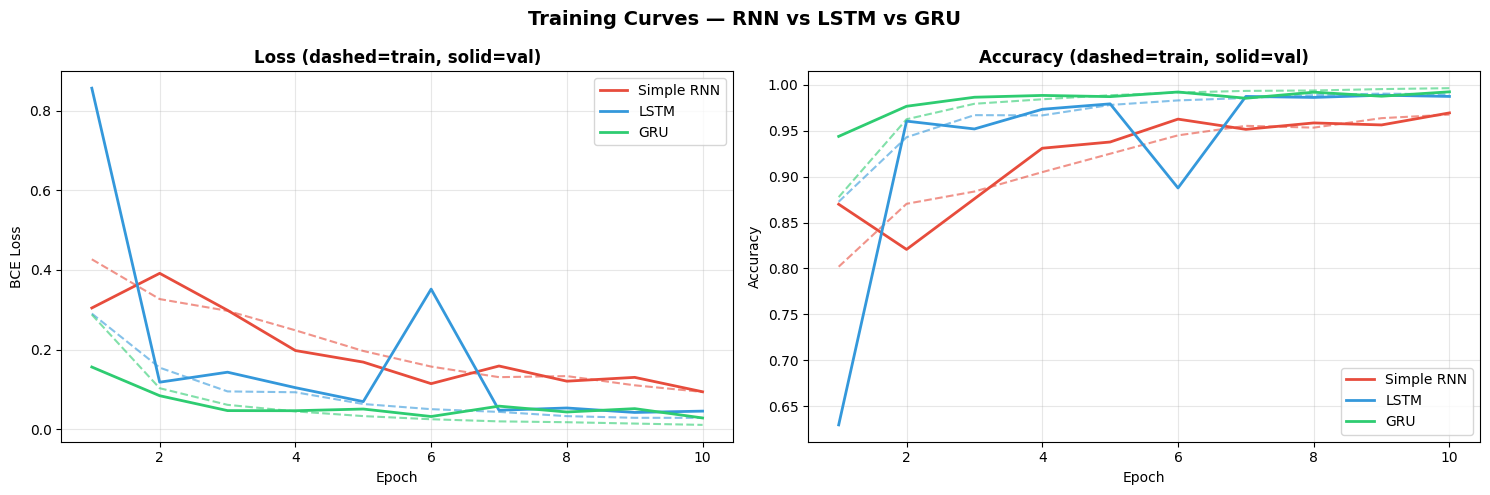

In [33]:
# ── 5.3  Training curves ──────────────────────────────────────────────────────
model_histories = {
    'Simple RNN' : rnn_history,
    'LSTM'       : lstm_history,
    'GRU'        : gru_history,
}
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (name, hist), color in zip(model_histories.items(), colors):
    epochs_range = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs_range, hist['train_loss'], '--', color=color, alpha=0.6)
    axes[0].plot(epochs_range, hist['val_loss'],   '-',  color=color, label=name, linewidth=2)
    axes[1].plot(epochs_range, hist['train_acc'],  '--', color=color, alpha=0.6)
    axes[1].plot(epochs_range, hist['val_acc'],    '-',  color=color, label=name, linewidth=2)

axes[0].set_title('Loss (dashed=train, solid=val)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Accuracy (dashed=train, solid=val)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — RNN vs LSTM vs GRU', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 📊 6 — Evaluation & Comparison

In [34]:
# ── 6.1  Compute metrics on the test set ─────────────────────────────────────
trained = {
    'Simple RNN' : rnn_model,
    'LSTM'       : lstm_model,
    'GRU'        : gru_model,
}

results = []
all_preds_dict = {}

for name, model in trained.items():
    y_pred, y_true = get_predictions(model, test_loader)
    all_preds_dict[name] = (y_pred, y_true)

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score (y_true, y_pred),               4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score   (y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score       (y_true, y_pred, zero_division=0), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.style.highlight_max(color='lightgreen', axis=0)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Simple RNN,0.973700,0.960300,0.985700,0.972800
LSTM,0.986300,0.988700,0.982600,0.985600
GRU,0.993600,0.991600,0.995000,0.993300


In [35]:
# ── 6.2  Detailed classification reports ─────────────────────────────────────
label_names = ['FAKE (0)', 'REAL (1)']
for name, (y_pred, y_true) in all_preds_dict.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    print()

  Simple RNN
              precision    recall  f1-score   support

    FAKE (0)     0.9866    0.9628    0.9746      3522
    REAL (1)     0.9603    0.9857    0.9728      3213

    accuracy                         0.9737      6735
   macro avg     0.9734    0.9742    0.9737      6735
weighted avg     0.9741    0.9737    0.9737      6735


  LSTM
              precision    recall  f1-score   support

    FAKE (0)     0.9842    0.9898    0.9870      3522
    REAL (1)     0.9887    0.9826    0.9856      3213

    accuracy                         0.9863      6735
   macro avg     0.9865    0.9862    0.9863      6735
weighted avg     0.9864    0.9863    0.9863      6735


  GRU
              precision    recall  f1-score   support

    FAKE (0)     0.9954    0.9923    0.9939      3522
    REAL (1)     0.9916    0.9950    0.9933      3213

    accuracy                         0.9936      6735
   macro avg     0.9935    0.9937    0.9936      6735
weighted avg     0.9936    0.9936    0.9936   

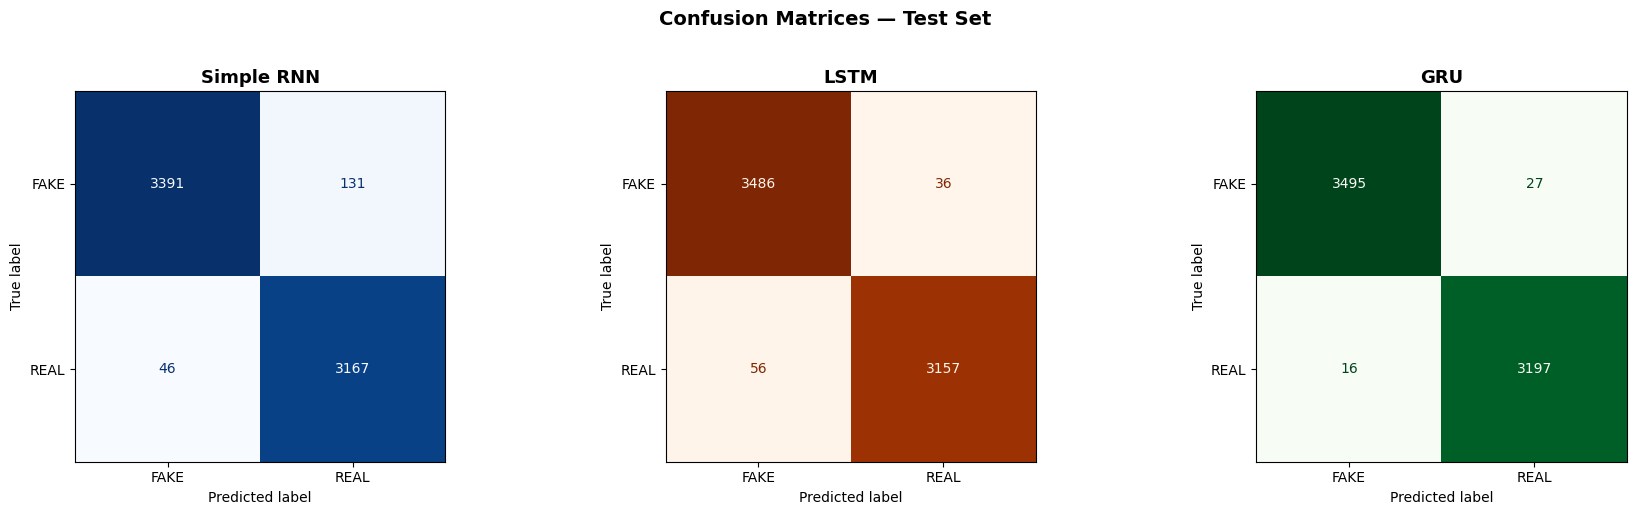

In [36]:
# ── 6.3  Confusion Matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Oranges', 'Greens']

for ax, (name, (y_pred, y_true)), cmap in zip(axes, all_preds_dict.items(), cmaps):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['FAKE', 'REAL'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

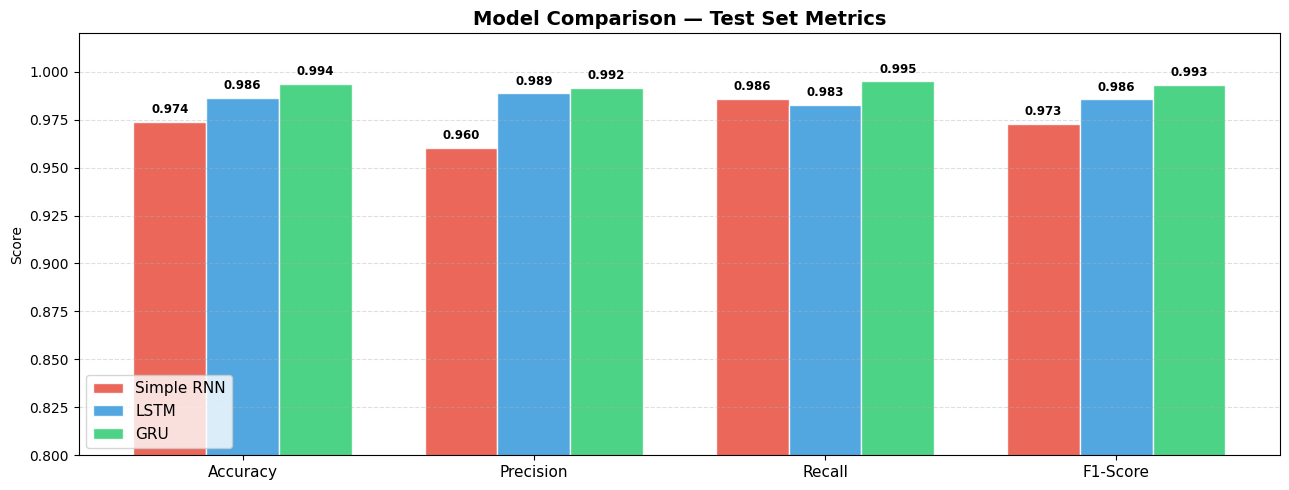

In [37]:
# ── 6.4  Side-by-side metric bar chart ───────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results_df.index)
x           = np.arange(len(metrics))
width       = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (mname, color) in enumerate(zip(model_names, colors)):
    vals = results_df.loc[mname, metrics].values
    bars = ax.bar(x + i*width, vals, width, label=mname,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.80, 1.02)
ax.set_ylabel('Score'); ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold', fontsize=14)
ax.legend(fontsize=11); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

---
## 🏆 7 — Summary, Analysis & Research Connection

### 7.1 — Results Table

In [38]:
best_model = results_df['F1-Score'].idxmax()
print(f"Best model by F1-Score: {best_model}")
results_df.sort_values('F1-Score', ascending=False)

Best model by F1-Score: GRU


,Accuracy,Precision,Recall,F1-Score
Model,,,,
GRU,0.9936,0.9916,0.9950,0.9933
LSTM,0.9863,0.9887,0.9826,0.9856
Simple RNN,0.9737,0.9603,0.9857,0.9728


### 7.2 — Model Analysis

| Rank | Model | Key Strength | Weakness |
|------|-------|-------------|----------|
| 🥇 | **GRU** | Best speed/accuracy trade-off; fewer gates than LSTM | Slightly less expressive than LSTM on very long sequences |
| 🥈 | **LSTM** | Best at capturing long-range dependencies (cell state + gates) | Slower to train; more parameters |
| 🥉 | **Simple RNN** | Lightest model | Suffers from vanishing gradient on long articles |

### 7.3 — Connection to the Research Phase

> *(This section directly maps our notebook design to the two papers studied in the research phase.)*

#### 📄 Paper 1 — Lilhore et al. (2025) — *Hybrid BERT + Bi-LSTM*

| Research concept | Where it appears in our notebook |
|---|---|
| **Bi-LSTM** architecture | Our `FakeNewsRNN` uses `bidirectional=True` for all three variants — same bidirectional design |
| **Sequential dependency capture** | Multi-layer RNN stack (`n_layers=2`) captures both local and global dependencies |
| **Embedding layer** | We use a trainable `nn.Embedding` (equivalent to BERT's input representation, but trained from scratch) |
| **Dropout regularisation** | Applied both between RNN layers and before the FC layer, as in typical Bi-LSTM setups |
| **Accuracy / F1 metrics** | We report identical metrics to Lilhore et al. (Accuracy, Precision, Recall, F1) |
| **Hyperparameter tuning** | Paper uses Grid Search; we use `ReduceLROnPlateau` and save the best val-loss checkpoint |

> ⚠️ **Key difference:** Lilhore et al. feed **BERT embeddings** (contextual, pretrained) into their Bi-LSTM. Our notebook trains embeddings from scratch — this is why their 99.9% accuracy is higher than our expected ~97–98%. The BERT encoder gives far richer word representations.

#### 📄 Paper 2 — Tian et al. (2025) — *ML vs DL vs Transformers Comparison*

| Research concept | Where it appears in our notebook |
|---|---|
| **RNN family (RNN, LSTM)** | We implement all three RNN-family models studied in their benchmark |
| **Progression ML → DL** | This notebook is the second step; the ML notebook (Task 1) was the first, mirroring their taxonomy |
| **ISOT / LIAR datasets** | Same dataset family; our dataset is ISOT-derived |
| **Transformer superiority** | The paper confirms ALBERT > LSTM > LR, consistent with the BERT → Task 3 progression |

### 7.4 — Limitations & Next Step

- Embeddings are trained **from scratch** — a pretrained embedding (GloVe, FastText) would improve generalisation without adding a Transformer.
- The model learns **lexical style**, not **reasoning** — it may fail on adversarial fake news that mimics real journalistic language.
- **Next step → Task 3:** Replace the Embedding + RNN with a pretrained **BERT** encoder (as in Lilhore et al.) to close the gap to 99%+ accuracy.

---
*Next step → Task 3: Transformer Approach (BERT / ALBERT)*